# Modele lineaire - cas reel (chat / chien / autre)


In [1]:
import os
import sys
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join("..", "python")))

from model_linear import lib, entrainer_linear, precision_linear
from functions import melanger, load_dataset

## 1. Chargement du dataset

In [2]:
project_root = os.path.abspath("..")
train_folder = os.path.join(project_root, "dataset", "train_dataset")
test_folder = os.path.join(project_root, "dataset", "test_dataset")

X_train_32_1, Y_train_32_1 = load_dataset(train_folder, target_size=(32, 32))
X_test_32_1, Y_test_32_1 = load_dataset(test_folder, target_size=(32, 32))
X_train_32_3, Y_train_32_3 = load_dataset(train_folder, target_size=(32, 32), color=True)
X_test_32_3, Y_test_32_3 = load_dataset(test_folder, target_size=(32, 32), color=True)

X_train_16_1, Y_train_16_1 = load_dataset(train_folder, target_size=(16, 16))
X_test_16_1, Y_test_16_1 = load_dataset(test_folder, target_size=(16, 16))
X_train_16_3, Y_train_16_3 = load_dataset(train_folder, target_size=(16, 16), color=True)
X_test_16_3, Y_test_16_3 = load_dataset(test_folder, target_size=(16, 16), color=True)

print(f"32x32 -- train: {len(X_train_32_1)} (gris) / {len(X_train_32_3)} (couleur)")
print(f"16x16 -- train: {len(X_train_16_1)} (gris) / {len(X_train_16_3)} (couleur)")


32x32 -- train: 2400 (gris) / 2400 (couleur)
16x16 -- train: 2400 (gris) / 2400 (couleur)


## 2. Comparaison resolution / couleur

In [3]:
results = []  # historique de tous les runs

def run_linear(X_train, Y_train, X_test, Y_test, resolution, couleur, epochs, lr, n_train=None, seed=42):
    X_train, Y_train = melanger(X_train, Y_train, seed)
    X_train, Y_train = X_train[:n_train], Y_train[:n_train]

    model = entrainer_linear(X_train, Y_train, output_size=3, epochs=epochs, lr=lr, shuffle=False)

    r = {
        "resolution": resolution, "couleur": couleur, "epochs": epochs, "lr": lr,
        "n_train": len(X_train),
        "train_acc": precision_linear(model, X_train, Y_train),
        "test_acc": precision_linear(model, X_test, Y_test),
    }
    results.append(r)

    canal = "couleur" if couleur else "gris"
    print(f"{resolution}x{resolution} {canal} | epochs={epochs} lr={lr} n_train={r['n_train']} "
          f"-> train={r['train_acc']:.2f}% test={r['test_acc']:.2f}%")

    lib.destroy_linear_model(model)


PEU_IMAGES = 500
PEU_EPOCHS = 200
PLUS_EPOCHS = 1000
LR = 0.0001


### 16x16

In [4]:
run_linear(X_train_16_1, Y_train_16_1, X_test_16_1, Y_test_16_1, 16, False, PEU_EPOCHS, LR, n_train=PEU_IMAGES)
run_linear(X_train_16_1, Y_train_16_1, X_test_16_1, Y_test_16_1, 16, False, PEU_EPOCHS, LR)
run_linear(X_train_16_1, Y_train_16_1, X_test_16_1, Y_test_16_1, 16, False, PLUS_EPOCHS, LR)

run_linear(X_train_16_3, Y_train_16_3, X_test_16_3, Y_test_16_3, 16, True, PEU_EPOCHS, LR, n_train=PEU_IMAGES)
run_linear(X_train_16_3, Y_train_16_3, X_test_16_3, Y_test_16_3, 16, True, PEU_EPOCHS, LR)
run_linear(X_train_16_3, Y_train_16_3, X_test_16_3, Y_test_16_3, 16, True, PLUS_EPOCHS, LR)


16x16 gris | epochs=200 lr=0.0001 n_train=500 -> train=56.20% test=40.00%


16x16 gris | epochs=200 lr=0.0001 n_train=2400 -> train=50.50% test=44.17%


16x16 gris | epochs=1000 lr=0.0001 n_train=2400 -> train=53.29% test=41.00%


16x16 couleur | epochs=200 lr=0.0001 n_train=500 -> train=68.60% test=47.67%


16x16 couleur | epochs=200 lr=0.0001 n_train=2400 -> train=59.88% test=52.50%


16x16 couleur | epochs=1000 lr=0.0001 n_train=2400 -> train=63.29% test=49.17%


### 32x32

In [5]:
run_linear(X_train_32_1, Y_train_32_1, X_test_32_1, Y_test_32_1, 32, False, PEU_EPOCHS, LR, n_train=PEU_IMAGES)
run_linear(X_train_32_1, Y_train_32_1, X_test_32_1, Y_test_32_1, 32, False, PEU_EPOCHS, LR)
run_linear(X_train_32_1, Y_train_32_1, X_test_32_1, Y_test_32_1, 32, False, PLUS_EPOCHS, LR)

run_linear(X_train_32_3, Y_train_32_3, X_test_32_3, Y_test_32_3, 32, True, PEU_EPOCHS, LR, n_train=PEU_IMAGES)
run_linear(X_train_32_3, Y_train_32_3, X_test_32_3, Y_test_32_3, 32, True, PEU_EPOCHS, LR)
run_linear(X_train_32_3, Y_train_32_3, X_test_32_3, Y_test_32_3, 32, True, PLUS_EPOCHS, LR)


32x32 gris | epochs=200 lr=0.0001 n_train=500 -> train=77.00% test=38.67%


32x32 gris | epochs=200 lr=0.0001 n_train=2400 -> train=62.50% test=38.83%


32x32 gris | epochs=1000 lr=0.0001 n_train=2400 -> train=70.50% test=39.33%


32x32 couleur | epochs=200 lr=0.0001 n_train=500 -> train=91.60% test=41.50%


32x32 couleur | epochs=200 lr=0.0001 n_train=2400 -> train=74.92% test=46.50%


32x32 couleur | epochs=1000 lr=0.0001 n_train=2400 -> train=83.21% test=44.17%


## 3. Recap final

In [6]:
top5 = sorted(results, key=lambda r: r["test_acc"], reverse=True)[:5]

print(f"{'Config':<14}{'N_train':>9}{'Epochs':>8}{'LR':>10}{'Train%':>9}{'Test%':>8}")
print("-" * 58)
for r in top5:
    canal = "couleur" if r["couleur"] else "gris"
    config = f"{r['resolution']}x{r['resolution']} {canal}"
    print(f"{config:<14}{r['n_train']:>9}{r['epochs']:>8}{r['lr']:>10}{r['train_acc']:>8.2f}%{r['test_acc']:>7.2f}%")


Config          N_train  Epochs        LR   Train%   Test%
----------------------------------------------------------
16x16 couleur      2400     200    0.0001   59.88%  52.50%
16x16 couleur      2400    1000    0.0001   63.29%  49.17%
16x16 couleur       500     200    0.0001   68.60%  47.67%
32x32 couleur      2400     200    0.0001   74.92%  46.50%
16x16 gris         2400     200    0.0001   50.50%  44.17%


## 4. Courbes d'apprentissage

A partir d'ici on fixe une config (16x16 couleur) pour etudier l'effet de chaque
parametre independamment. Deux petites fonctions pour eviter de repeter le code
des graphiques :


In [7]:
def courbe(x, y, xlabel, ylabel, titre, log=False):
    plt.plot(x, y, marker="o")
    if log:
        plt.xscale("log")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(titre)
    plt.show()

def courbe_train_test(hist_train, hist_test, ylabel, titre):
    plt.plot(hist_train, label="train")
    plt.plot(hist_test, label="test")
    plt.xlabel("epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.title(titre)
    plt.show()


### 4.1 Precision et erreur au fil des epochs

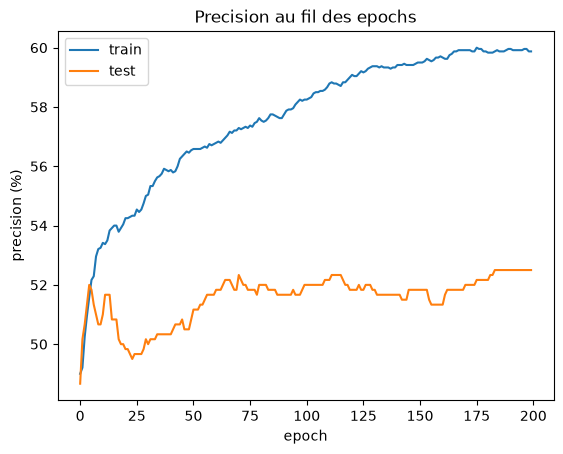

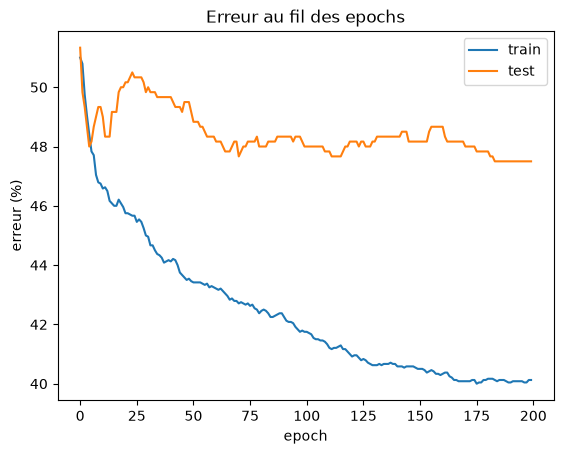

In [8]:
model, hist_train, hist_test = entrainer_linear(
    X_train_16_3, Y_train_16_3, output_size=3, epochs=200, lr=LR,
    X_test=X_test_16_3, Y_test=Y_test_16_3)
lib.destroy_linear_model(model)

courbe_train_test(hist_train, hist_test, "precision (%)", "Precision au fil des epochs")
courbe_train_test([100 - p for p in hist_train], [100 - p for p in hist_test], "erreur (%)", "Erreur au fil des epochs")

### 4.2 Effet du learning rate

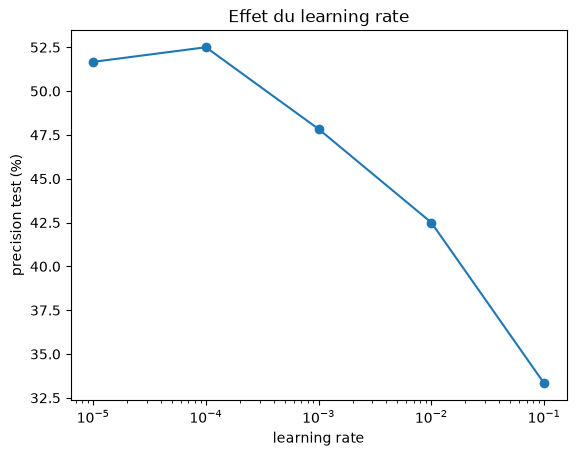

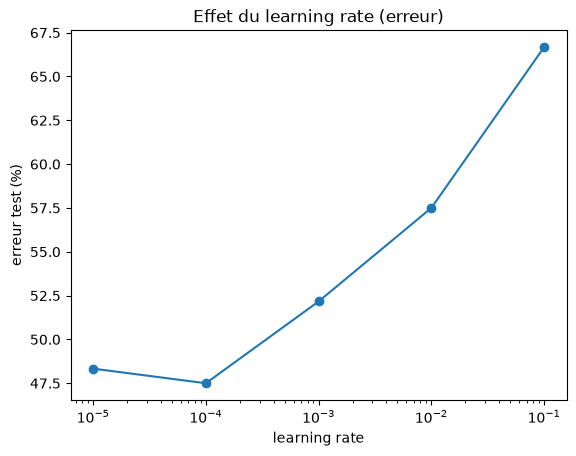

In [9]:
lrs = [0.1, 0.01, 0.001, 0.0001, 0.00001]
accs = []
for lr in lrs:
    model = entrainer_linear(X_train_16_3, Y_train_16_3, output_size=3, epochs=200, lr=lr)
    accs.append(precision_linear(model, X_test_16_3, Y_test_16_3))
    lib.destroy_linear_model(model)

courbe(lrs, accs, "learning rate", "precision test (%)", "Effet du learning rate", log=True)
courbe(lrs, [100 - a for a in accs], "learning rate", "erreur test (%)", "Effet du learning rate (erreur)", log=True)


### 4.3 Effet du nombre d'images

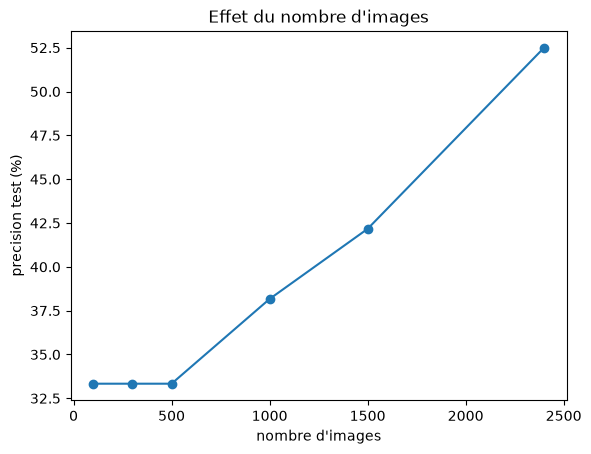

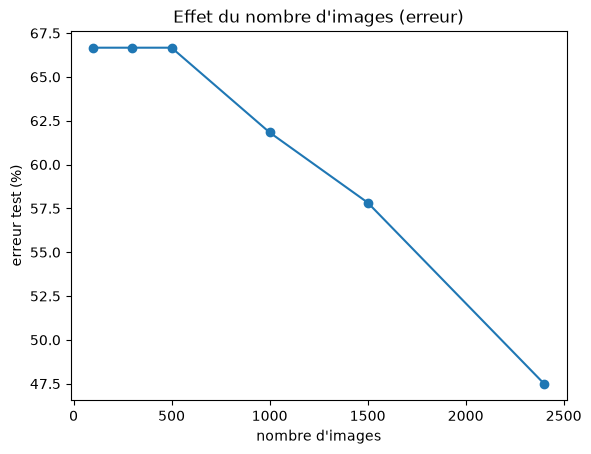

In [10]:
tailles = [100, 300, 500, 1000, 1500, 2400]
accs = []
for n in tailles:
    model = entrainer_linear(X_train_16_3[:n], Y_train_16_3[:n], output_size=3, epochs=200, lr=LR)
    accs.append(precision_linear(model, X_test_16_3, Y_test_16_3))
    lib.destroy_linear_model(model)

courbe(tailles, accs, "nombre d'images", "precision test (%)", "Effet du nombre d'images")
courbe(tailles, [100 - a for a in accs], "nombre d'images", "erreur test (%)", "Effet du nombre d'images (erreur)")


## 5. Sauvegarde du meilleur modele

Config retenue : 16x16 couleur, 200 epochs, lr=0.0001.


In [11]:
model = entrainer_linear(X_train_16_3, Y_train_16_3, output_size=3, epochs=200, lr=LR, shuffle=True, seed=42)

chemin = os.path.join(project_root, "models", "linear_chat_chien_autre.txt")
lib.save_linear_model(model, chemin.encode())
lib.destroy_linear_model(model)

print("modele sauvegarde")


modele sauvegarde


### Chargement (sans reentrainer)

In [12]:
model_charge = lib.load_linear_model(chemin.encode())
print(f"test_acc (modele recharge) = {precision_linear(model_charge, X_test_16_3, Y_test_16_3):.2f}%")
lib.destroy_linear_model(model_charge)


test_acc (modele recharge) = 52.50%
